# AI-Powered Personal Spending & Financial Behavior Coach
## Notebook 02 — Exploratory Data Analysis (EDA)

### Purpose of EDA (Business-Oriented)
This EDA focuses on using visualizations as exploration artifacts to:

1) Understand the business workflow this solution integrates into  
2) Understand key data entities and their relationships (Customer, Time, Category, Merchant)  
3) Identify ML model types that align with business goals  
4) Ideate integration into a user-facing product workflow  
5) Define how we will evaluate success (KPIs + evaluation design)

Note: Customer-level clustering validation will be addressed in the Modeling notebook (Notebook 04),
since it relies on engineered customer features and model-driven segmentation.

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

# Helper to add value labels on bar charts
def add_bar_labels(ax, fmt="{:,.0f}", rotation=0):
    for p in ax.patches:
        value = p.get_height()
        if np.isnan(value):
            continue
        ax.annotate(
            fmt.format(value),
            (p.get_x() + p.get_width() / 2, value),
            ha="center",
            va="bottom",
            fontsize=10,
            rotation=rotation,
            xytext=(0, 3),
            textcoords="offset points"
        )

In [76]:
df = pd.read_csv("cleaned_transactions.csv")

# If dates were saved as strings, parse again safely
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["birthdate"] = pd.to_datetime(df["birthdate"], errors="coerce")

df.head()

,customer_id,name,surname,gender,birthdate,transaction_amount,date,merchant_name,category,merchant_name_clean,year,month,day,weekday,age,age_group
0,752858,Sean,Rodriguez,F,2002-10-20,35.47,2023-04-03,Smith-Russell,Cosmetic,smith russell,2023,4,3,Monday,23,18-25
1,26381,Michelle,Phelps,Unknown,1985-10-24,2552.72,2023-07-17,"Peck, Spence and Young",Travel,peck spence and young,2023,7,17,Monday,40,36-45
2,305449,Jacob,Williams,M,1981-10-25,115.97,2023-09-20,Steele Inc,Clothing,steele inc,2023,9,20,Wednesday,44,36-45
3,988259,Nathan,Snyder,M,1977-10-26,11.31,2023-01-11,"Wilson, Wilson and Russell",Cosmetic,wilson wilson and russell,2023,1,11,Wednesday,48,46-55
4,764762,Crystal,Knapp,F,1951-11-02,62.21,2023-06-13,Palmer-Hinton,Electronics,palmer hinton,2023,6,13,Tuesday,74,65+


## 1) Business Workflow Understanding (DFD Narrative)

### Current workflow (without AI)
Customer → Transactions recorded → Static category charts → Customer guesses what to do next

Limitations:
- Charts show "what", not "why"
- No personas / segmentation
- No tailored recommendations
- Lower engagement and weaker behavior change

### Proposed workflow (with AI coach)
Customer → Transactions → Aggregation + behavior features → Persona segmentation →
LLM summary → Coaching recommendations surfaced in app

EDA goal here:
Validate that the dataset supports this workflow and define what behaviors are observable.

## 2) Understand the Data Entities and Relationships (Data Cube View)

Key entities & dimensions:
- Customer (customer_id)
- Time (date → year/month/weekday)
- Merchant (merchant_name_clean)
- Category (category)
- Demographics (age_group, gender)

EDA explores these dimensions to understand behavior patterns and inform modeling.

In [80]:
summary = {
    "rows": len(df),
    "unique_customers": df["customer_id"].nunique(),
    "unique_merchants": df["merchant_name_clean"].nunique() if "merchant_name_clean" in df.columns else df["merchant_name"].nunique(),
    "unique_categories": df["category"].nunique(),
    "date_min": df["date"].min(),
    "date_max": df["date"].max(),
}

summary

{'rows': 50000,
 'unique_customers': 50000,
 'unique_merchants': 36939,
 'unique_categories': 6,
 'date_min': Timestamp('2023-01-01 00:00:00'),
 'date_max': Timestamp('2023-10-14 00:00:00')}

## 3) Category Exploration (Business Levers)

Business question:
Which categories drive the largest portion of spend?

Why it matters:
If coaching influences a few dominant categories, it can create outsized impact.

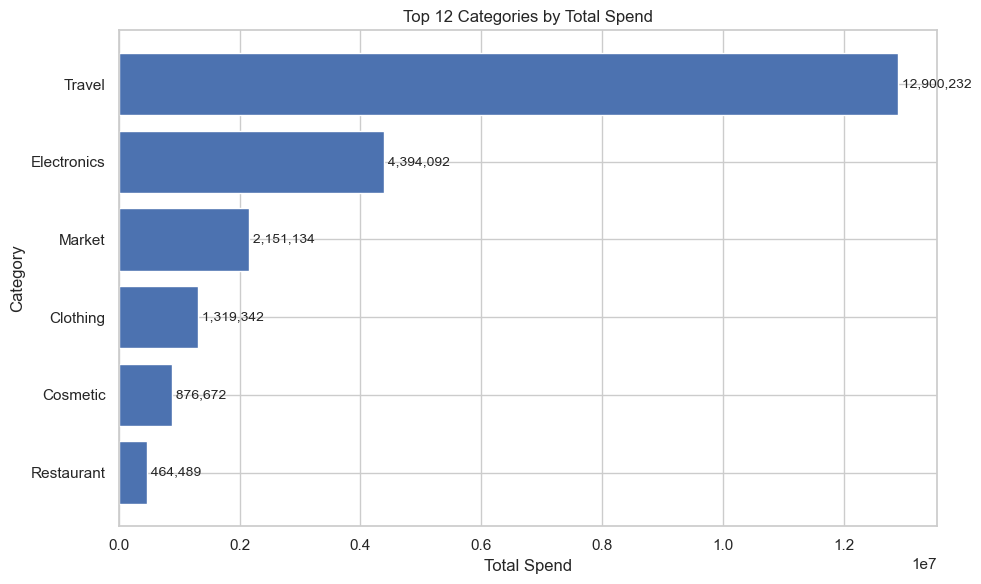

In [83]:
cat_total = (
    df.groupby("category")["transaction_amount"]
      .sum()
      .sort_values(ascending=False)
      .head(12)
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(cat_total.index[::-1], cat_total.values[::-1])
ax.set_title("Top 12 Categories by Total Spend")
ax.set_xlabel("Total Spend")
ax.set_ylabel("Category")

# Add labels to each bar
for i, v in enumerate(cat_total.values[::-1]):
    ax.text(v, i, f" {v:,.0f}", va="center", fontsize=10)

plt.tight_layout()
plt.show()

### Category Frequency (Habits vs Big Purchases)

Business question:
Are the biggest categories big because of **many small transactions** or **few large ones**?

Why it matters:
- Habit coaching targets frequent categories (e.g., coffee/food)
- Budget coaching targets high-ticket categories (e.g., travel)

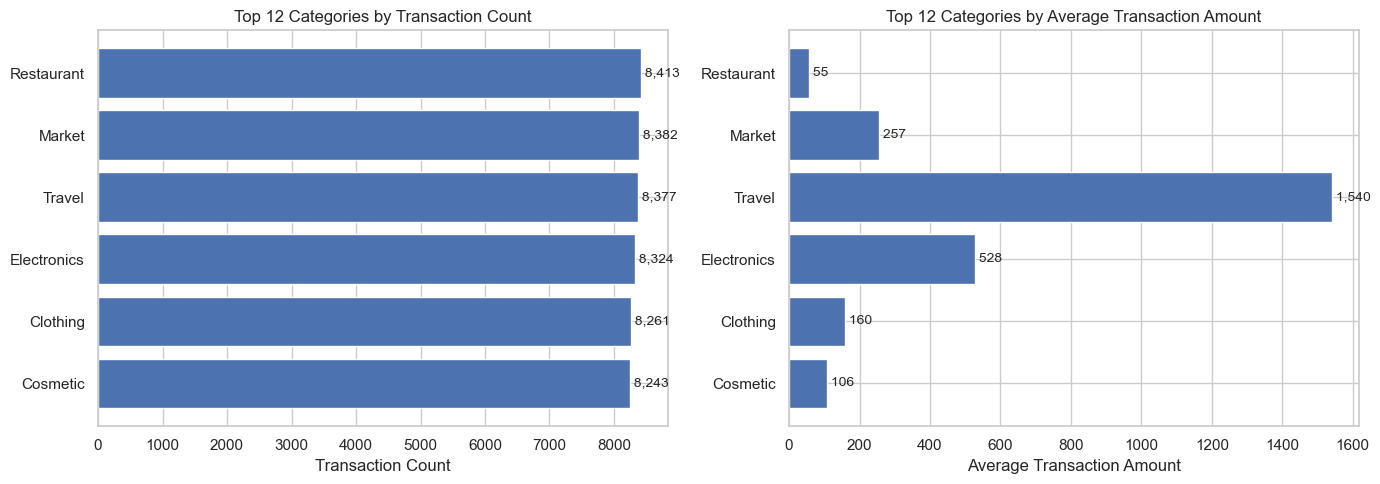

In [86]:
cat_stats = df.groupby("category")["transaction_amount"].agg(["mean", "count"]).sort_values("count", ascending=False).head(12)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count
axes[0].barh(cat_stats.index[::-1], cat_stats["count"].values[::-1])
axes[0].set_title("Top 12 Categories by Transaction Count")
axes[0].set_xlabel("Transaction Count")
for i, v in enumerate(cat_stats["count"].values[::-1]):
    axes[0].text(v, i, f" {int(v):,}", va="center", fontsize=10)

# Mean
axes[1].barh(cat_stats.index[::-1], cat_stats["mean"].values[::-1])
axes[1].set_title("Top 12 Categories by Average Transaction Amount")
axes[1].set_xlabel("Average Transaction Amount")
for i, v in enumerate(cat_stats["mean"].values[::-1]):
    axes[1].text(v, i, f" {v:,.0f}", va="center", fontsize=10)

plt.tight_layout()
plt.show()

## 4) Time Patterns (Seasonality & Workflow Timing)

Business question:
Does spending vary across months (seasonality) and weekdays (routine)?

Why it matters:
- Strong seasonality may require time-series modeling or seasonal features
- Weekday patterns can power "nudges" and timing of recommendations

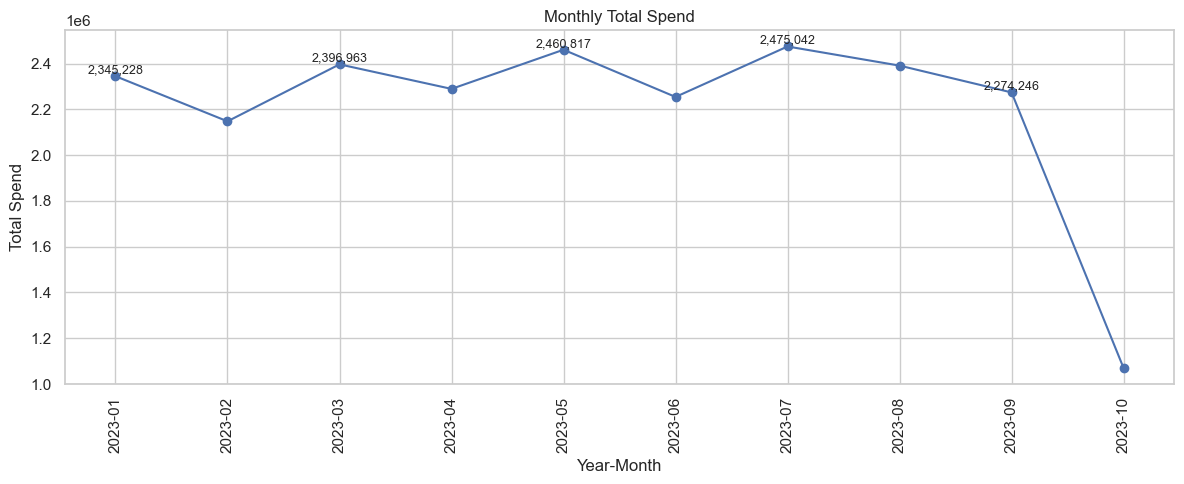

In [89]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

monthly = df.groupby(["year", "month"])["transaction_amount"].sum().reset_index()
monthly["year_month"] = monthly["year"].astype(str) + "-" + monthly["month"].astype(str).str.zfill(2)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly["year_month"], monthly["transaction_amount"], marker="o")
ax.set_title("Monthly Total Spend")
ax.set_xlabel("Year-Month")
ax.set_ylabel("Total Spend")
ax.tick_params(axis="x", rotation=90)

# Add labels to points (keep it readable: label every 2nd point)
for i, (x, y) in enumerate(zip(monthly["year_month"], monthly["transaction_amount"])):
    if i % 2 == 0:
        ax.text(i, y, f"{y:,.0f}", fontsize=9, ha="center", va="bottom")

plt.tight_layout()
plt.show()

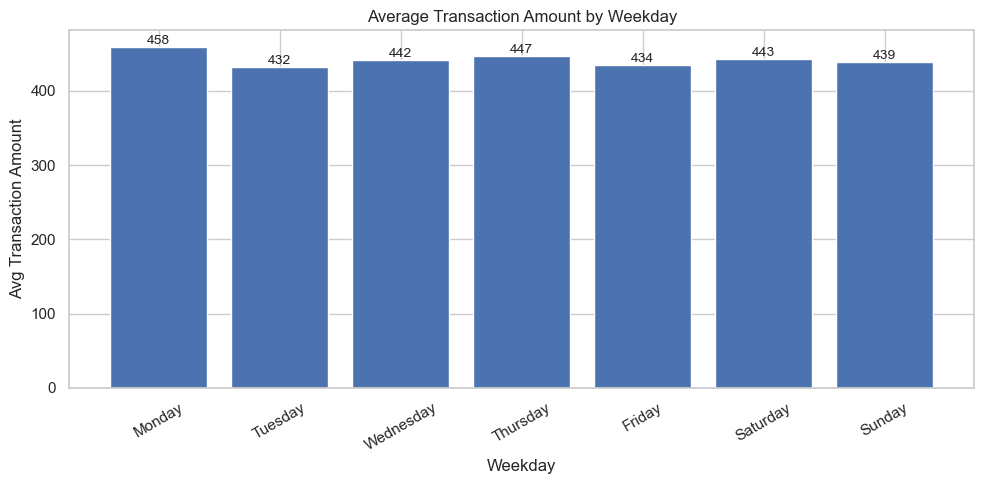

In [91]:
weekday_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
df["weekday"] = df["date"].dt.day_name()

weekday_avg = df.groupby("weekday")["transaction_amount"].mean().reindex(weekday_order)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(weekday_avg.index, weekday_avg.values)
ax.set_title("Average Transaction Amount by Weekday")
ax.set_xlabel("Weekday")
ax.set_ylabel("Avg Transaction Amount")
ax.tick_params(axis="x", rotation=30)

# Add labels
for i, v in enumerate(weekday_avg.values):
    ax.text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

## 5) Merchant Concentration (Personalization Opportunity)

Business question:
Are customers concentrated around a small set of merchants?

Why it matters:
- High concentration → easier to personalize coaching ("Your top merchants are X, Y, Z")
- Useful for merchant-based anomaly detection later

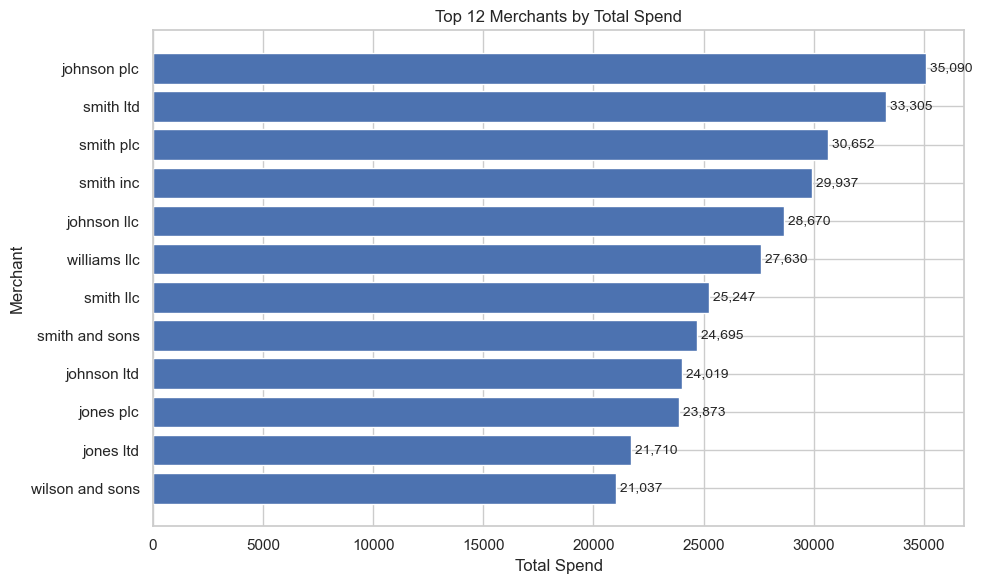

In [94]:
merchant_col = "merchant_name_clean" if "merchant_name_clean" in df.columns else "merchant_name"

top_merchants = (
    df.groupby(merchant_col)["transaction_amount"]
      .sum()
      .sort_values(ascending=False)
      .head(12)
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_merchants.index[::-1], top_merchants.values[::-1])
ax.set_title("Top 12 Merchants by Total Spend")
ax.set_xlabel("Total Spend")
ax.set_ylabel("Merchant")

for i, v in enumerate(top_merchants.values[::-1]):
    ax.text(v, i, f" {v:,.0f}", va="center", fontsize=10)

plt.tight_layout()
plt.show()

## 6) Demographic Lens

Business question:
Do age group and gender show meaningful differences in spending behavior?

Why it matters:
- If differences are strong, demographics can be used as clustering features
- If weak, demographics can be used mainly for reporting & UX personalization

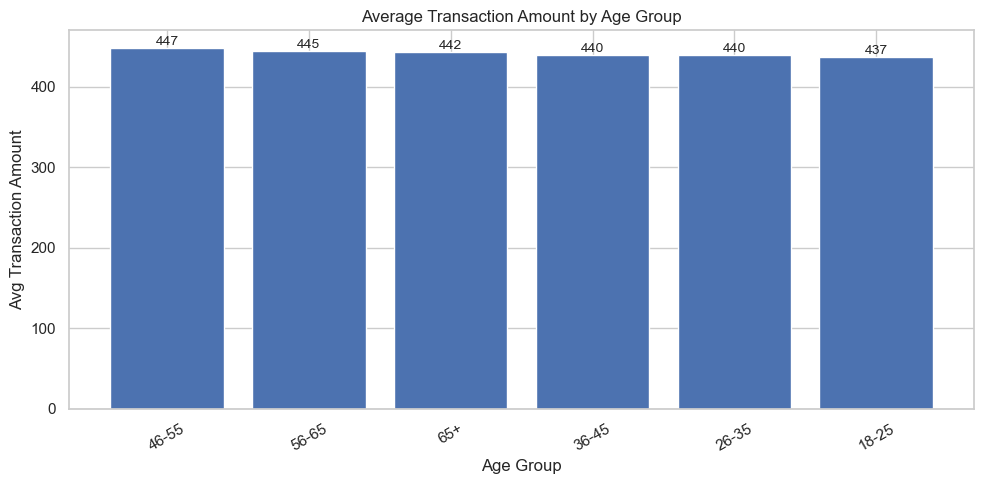

In [97]:
if "age_group" in df.columns:
    age_avg = df.groupby("age_group")["transaction_amount"].mean().sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(age_avg.index.astype(str), age_avg.values)
    ax.set_title("Average Transaction Amount by Age Group")
    ax.set_xlabel("Age Group")
    ax.set_ylabel("Avg Transaction Amount")
    ax.tick_params(axis="x", rotation=30)

    for i, v in enumerate(age_avg.values):
        ax.text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=10)

    plt.tight_layout()
    plt.show()
else:
    print("age_group not found in dataset.")

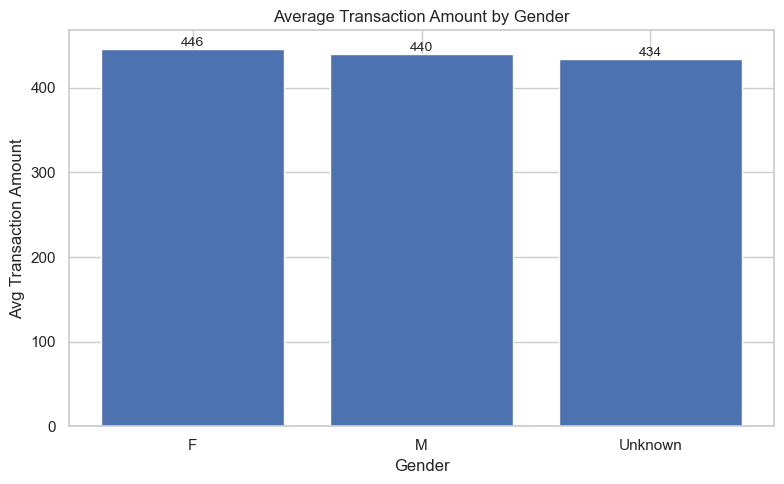

In [99]:
gender_avg = df.groupby("gender")["transaction_amount"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(gender_avg.index.astype(str), gender_avg.values)
ax.set_title("Average Transaction Amount by Gender")
ax.set_xlabel("Gender")
ax.set_ylabel("Avg Transaction Amount")

for i, v in enumerate(gender_avg.values):
    ax.text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

### Handling of Missing Gender Values

Approximately 10% of records had missing gender values in the raw dataset.
Rather than dropping these records (which would reduce sample size and
potentially introduce bias), missing values were labeled as "Unknown".

EDA shows that the "Unknown" group exhibits similar average transaction
behavior compared to other groups, suggesting missingness is not strongly
associated with spending differences.

Therefore, gender will be treated as contextual information rather than a
primary segmentation variable in modeling.

## 7) ML Model Alignment (What EDA Suggests)

Based on EDA:

- We observe meaningful variation across categories, merchants, and time patterns.
- The dataset supports customer segmentation and personalized messaging.

Recommended ML components:
1) Unsupervised clustering (personas) — built on customer-level engineered features (Notebook 04)
2) LLM generation — convert behavioral features into understandable summaries and coaching
3) Optional anomaly detection — detect unusual spikes or merchant/category shifts

## 8) How This Becomes a Data Product

Proposed user experience:
- Customer selects profile (or logs in)
- System shows:
  - Top categories and merchants
  - Trend over time
  - AI-generated summary ("You tend to spend most on…")
  - One coaching suggestion

Deployment plan:
- Streamlit app hosted on Hugging Face
- Loads customer features + transaction summaries
- LLM generates coaching insights at request time

## 9) Evaluation Framework (KPIs + A/B Testing)

Primary KPIs (behavior change):
- Reduction in discretionary category spend (e.g., dining, shopping)
- Reduction in spending volatility over time
- Increase in budget adherence (proxy: fewer overspend months)

Engagement KPIs (product success):
- Insight view rate
- Repeat usage rate (weekly active users)
- Recommendation click-through (if implemented)

Evaluation method:
- A/B test:
  - Control: standard charts only
  - Treatment: AI coaching enabled
- Compare KPI deltas across 30-day windows

## 10) EDA Conclusions

EDA confirms:
- Spend is meaningfully structured by category and merchant
- Time patterns exist and can support behavioral nudges
- Demographics may add context but are not strictly required for segmentation

Next step:
Build customer-level features and persona clustering in the modeling notebook,
then connect personas to LLM summaries in the deployed Hugging Face app.